# NGC 4395 Drizzle3D — Interactive Explorer

交互式探索 NGC 4395 的 Drizzle3D 数据立方体（X, Y, λ）。

**前置条件**
- 先运行 `python ngc4395_drizzle.py` 生成数据立方体
- 安装交互依赖：`pip install ipympl ipywidgets`

**功能**
1. Z-bin 滑块浏览：拖动滑块查看不同波长切片的图像
2. 点击选谱：在空间图上点击任意像素，查看该位置的光谱（含误差带）

In [1]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact
from pathlib import Path

from spxquery.drizzle3d.io import load_cube

# Locate cube via spxquery package path
import spxquery
_root = Path(spxquery.__file__).resolve().parent.parent.parent
DEMO_DIR = _root / "example" / "drizzle3d_demo"
CUBE_PATH = DEMO_DIR / "output" / "drizzle_D3.fits"
print(f"Cube: {CUBE_PATH}")
print(f"Exists: {CUBE_PATH.exists()}")

Cube: /Volumes/QuarkStar/20260518spxquery/spxquery/example/drizzle3d_demo/output/drizzle_D3.fits
Exists: True


In [2]:
data = load_cube(CUBE_PATH)
sci = data["sci"]            # (n_z, n_y, n_x)  [MJy/sr]
var = data["variance"]        # (n_z, n_y, n_x)
cnt = data["count"]           # (n_z, n_y, n_x)
wl  = data["wavelength"]      # LAMBDA column [μm]
hdr = data["header"]

n_z, n_y, n_x = sci.shape
lam_arr = wl["LAMBDA"]

print(f"Detector : D{hdr['DETECTOR']}")
print(f"Shape    : ({n_z}, {n_y}, {n_x})")
print(f"Inputs   : {hdr['N_INPUTS']} observations")
print(f"λ range  : [{lam_arr[0]:.4f}, {lam_arr[-1]:.4f}] μm")
print(f"Flux     : [{np.nanmin(sci):.2f}, {np.nanmax(sci):.2f}] MJy/sr")
print(f"Valid    : {np.sum(np.isfinite(sci))}/{sci.size}"
      f" ({np.sum(np.isfinite(sci))/sci.size:.1%})")

Detector : D3
Shape    : (17, 292, 292)
Inputs   : 38 observations
λ range  : [1.6555, 2.4035] μm
Flux     : [-6.20, 165.71] MJy/sr
Valid    : 1449488/1449488 (100.0%)


---
## 数据总览

Z 方向求和得到 collapsed coadd，标记峰值像素位置。

Peak pixel: (35, 172), coadd = 1647.6 MJy/sr


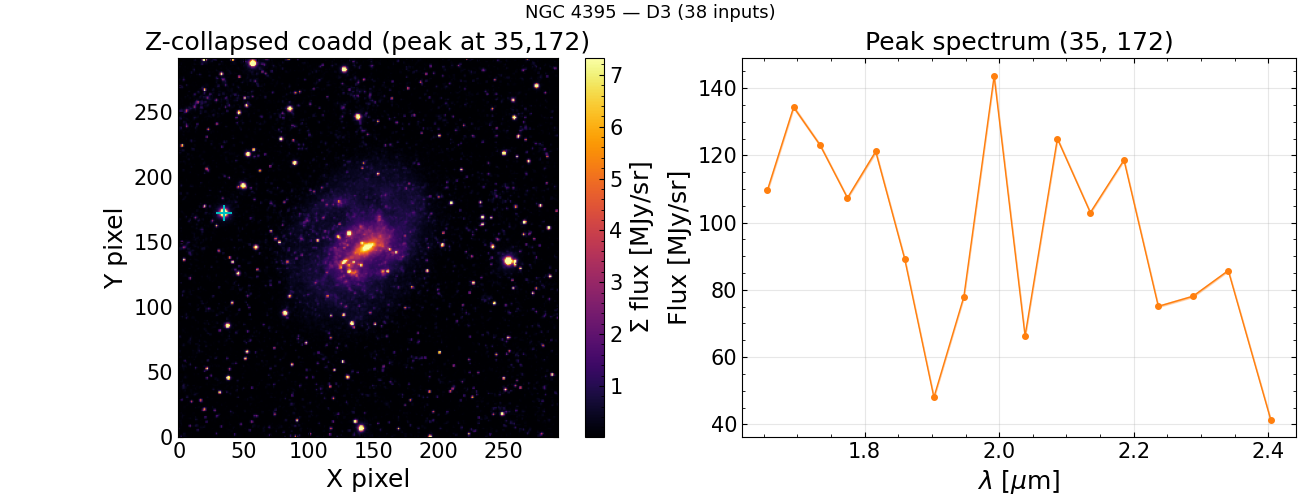

In [3]:
coadd = np.nansum(sci, axis=0)
peak_y, peak_x = np.unravel_index(np.nanargmax(coadd), coadd.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# Z-collapsed coadd
coadd_pos = np.where(coadd > 0, coadd, np.nan)
v1, v2 = np.nanpercentile(coadd_pos, 5), np.nanpercentile(coadd_pos, 99.5)
im = axes[0].imshow(coadd, origin="lower", cmap="inferno", vmin=v1, vmax=v2)
axes[0].plot(peak_x, peak_y, "c+", ms=12, mew=1.5)
axes[0].set_xlabel("X pixel")
axes[0].set_ylabel("Y pixel")
axes[0].set_title(f"Z-collapsed coadd (peak at {peak_x},{peak_y})")
plt.colorbar(im, ax=axes[0], label=r"$\Sigma$ flux [MJy/sr]")

# Spectrum at peak
spec_peak = sci[:, peak_y, peak_x]
sigma_peak = np.sqrt(var[:, peak_y, peak_x])
axes[1].fill_between(lam_arr, spec_peak - sigma_peak, spec_peak + sigma_peak,
                     alpha=0.3, color="C1")
axes[1].plot(lam_arr, spec_peak, "o-", color="C1", ms=4, lw=1)
axes[1].set_xlabel(r"$\lambda$ [$\mu$m]")
axes[1].set_ylabel("Flux [MJy/sr]")
axes[1].set_title(f"Peak spectrum ({peak_x}, {peak_y})")
axes[1].grid(True, alpha=0.3)

fig.suptitle(f"NGC 4395 — D{hdr['DETECTOR']} ({hdr['N_INPUTS']} inputs)", fontsize=13)
print(f"Peak pixel: ({peak_x}, {peak_y}), coadd = {coadd[peak_y, peak_x]:.1f} MJy/sr")

---
## Z-bin 浏览器

拖动滑块查看不同波长切片的图像。每个切片的颜色范围按该 bin 的 [1%, 99.5%] 百分位自适应。

interactive(children=(IntSlider(value=0, description='Z-bin', layout=Layout(width='500px'), max=16), Output())…

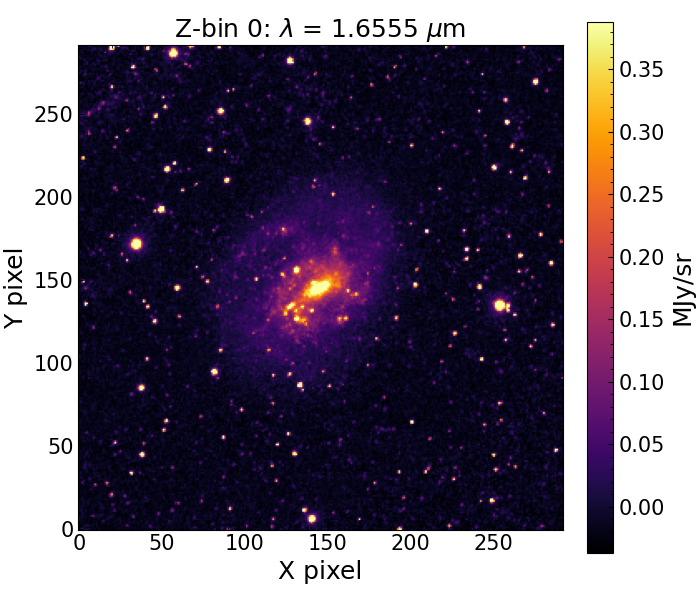

In [4]:
fig_z, ax_z = plt.subplots(figsize=(7, 6))
im_z = ax_z.imshow(sci[0], origin="lower", cmap="inferno")
cb_z = plt.colorbar(im_z, ax=ax_z, label="MJy/sr")
title_z = ax_z.set_title(f"Z-bin 0: $\\lambda$ = {lam_arr[0]:.4f} $\\mu$m")
ax_z.set_xlabel("X pixel")
ax_z.set_ylabel("Y pixel")

@interact(z_bin=widgets.IntSlider(
    min=0, max=n_z - 1, step=1, value=0,
    description="Z-bin",
    layout=widgets.Layout(width="500px")
))
def update_z(z_bin):
    img = sci[z_bin]
    v1, v2 = np.nanpercentile(img, [1, 99.5])
    im_z.set_data(img)
    im_z.set_clim(v1, v2)
    title_z.set_text(f"Z-bin {z_bin}: $\\lambda$ = {lam_arr[z_bin]:.4f} $\\mu$m")
    fig_z.canvas.draw_idle()

---
## 交互式光谱查看器

左图为 Z 方向中值空间图。**在左图上点击任意位置**，右图将显示该像素的完整光谱及误差带。

/var/folders/z5/qygyj_xj7dq109c9rzqq2wv40000gn/T/ipykernel_20354/4230945305.py:5: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig_sv.subplots_adjust(wspace=0.35)


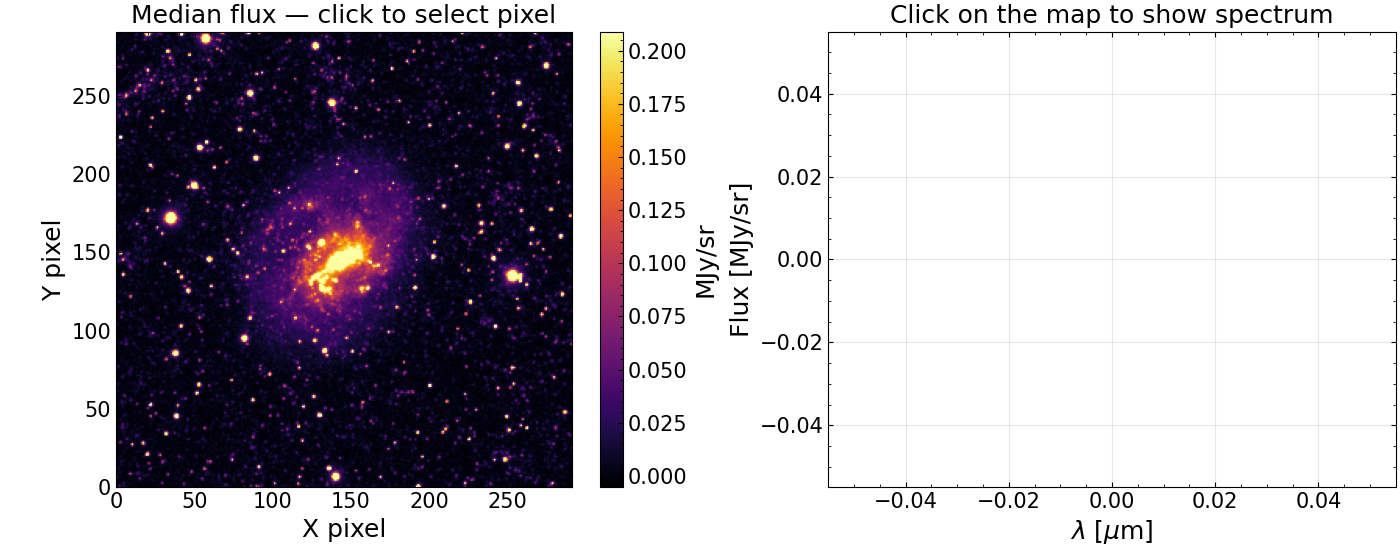

In [5]:
fig_sv, (ax_sky, ax_spec) = plt.subplots(
    1, 2, figsize=(14, 5.5),
    gridspec_kw={"width_ratios": [1, 1]}
)
fig_sv.subplots_adjust(wspace=0.35)

# Median-Z spatial map
median_map = np.nanmedian(sci, axis=0)
v1, v2 = np.nanpercentile(median_map, [1, 99])
im_sv = ax_sky.imshow(median_map, origin="lower", cmap="inferno",
                      vmin=v1, vmax=v2)
plt.colorbar(im_sv, ax=ax_sky, label="MJy/sr")
ax_sky.set_xlabel("X pixel")
ax_sky.set_ylabel("Y pixel")
ax_sky.set_title("Median flux — click to select pixel")

# Crosshair marker
(marker,) = ax_sky.plot([], [], "c+", ms=15, mew=2)

# Spectrum axes (empty initially)
(line_spec,) = ax_spec.plot([], [], "o-", color="C1", ms=4, lw=1)
ax_spec.set_xlabel(r"$\lambda$ [$\mu$m]")
ax_spec.set_ylabel("Flux [MJy/sr]")
ax_spec.set_title("Click on the map to show spectrum")
ax_spec.grid(True, alpha=0.3)

# Reference for error-band fill_between (mutable container)
_fill = [None]


def _on_click(event):
    if event.inaxes != ax_sky or event.button != 1:
        return
    x, y = int(round(event.xdata)), int(round(event.ydata))
    if not (0 <= x < n_x and 0 <= y < n_y):
        return

    spec = sci[:, y, x].astype(np.float64)
    sigma = np.sqrt(var[:, y, x].astype(np.float64))
    valid = np.isfinite(spec)

    # Update crosshair
    marker.set_data([x], [y])

    # Update spectrum line
    line_spec.set_data(lam_arr[valid], spec[valid])

    # Update error band
    if _fill[0] is not None:
        _fill[0].remove()
        _fill[0] = None
    if np.any(valid):
        _fill[0] = ax_spec.fill_between(
            lam_arr[valid],
            (spec - sigma)[valid],
            (spec + sigma)[valid],
            alpha=0.3, color="C1",
        )

    # Rescale axes
    ax_spec.set_xlim(lam_arr[0] - 0.02, lam_arr[-1] + 0.02)
    if np.any(valid):
        ylo, yhi = np.nanmin(spec[valid]), np.nanmax(spec[valid])
        margin = max(0.1 * (yhi - ylo), 0.01)
        ax_spec.set_ylim(ylo - margin, yhi + margin)
    ax_spec.set_title(f"Spectrum at ({x}, {y})")
    fig_sv.canvas.draw_idle()


_cid = fig_sv.canvas.mpl_connect("button_press_event", _on_click)
plt.show()